# 01 — Data Exploration

Ky notebook lexon dataset-in origjinal dhe kryen analizë fillestare **pa ndryshuar asnjë vlerë**.
Qëllimi është identifikimi i anomalive, outliers dhe inconsistencies para çdo pastrimi.

## 1. Importet dhe ngarkimi i dataset-it

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("../../data/raw/kc_house_data.csv")
Cdata = data.copy()
print("Shape:", data.shape)
data.head()

Shape: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## 2. Struktura e dataset-it


In [2]:
Cdata.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [3]:
Cdata.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [4]:
# Kontrollo duplikatet
Cdata.duplicated().sum()

np.int64(0)

In [5]:
Cdata.describe().round(2)

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00
mean,4.580302e+09,540088.14,3.37,2.11,2079.90,15106.97,1.49,0.01,0.23,3.41,7.66,1788.39,291.51,1971.01,84.40,98077.94,47.56,-122.21,1986.55,12768.46
std,2.876566e+09,367127.20,0.93,0.77,918.44,41420.51,0.54,0.09,0.77,0.65,1.18,828.09,442.58,29.37,401.68,53.51,0.14,0.14,685.39,27304.18
min,1.000102e+06,75000.00,0.00,0.00,290.00,520.00,1.00,0.00,0.00,1.00,1.00,290.00,0.00,1900.00,0.00,98001.00,47.16,-122.52,399.00,651.00
25%,2.123049e+09,321950.00,3.00,1.75,1427.00,5040.00,1.00,0.00,0.00,3.00,7.00,1190.00,0.00,1951.00,0.00,98033.00,47.47,-122.33,1490.00,5100.00
50%,3.904930e+09,450000.00,3.00,2.25,1910.00,7618.00,1.50,0.00,0.00,3.00,7.00,1560.00,0.00,1975.00,0.00,98065.00,47.57,-122.23,1840.00,7620.00
75%,7.308900e+09,645000.00,4.00,2.50,2550.00,10688.00,2.00,0.00,0.00,4.00,8.00,2210.00,560.00,1997.00,0.00,98118.00,47.68,-122.12,2360.00,10083.00
max,9.900000e+09,7700000.00,33.00,8.00,13540.00,1651359.00,3.50,1.00,4.00,5.00,13.00,9410.00,4820.00,2015.00,2015.00,98199.00,47.78,-121.32,6210.00,871200.00


## 3. Analiza e çmimeve (`price`)

Analiza statistikore e kolonës `price` tregon variacion të lartë me mesatare ~540,088 dhe devijim standard ~367,127.
Diferenca e madhe mes mesatares dhe maksimumit tregon prani të mundshme të outliers.

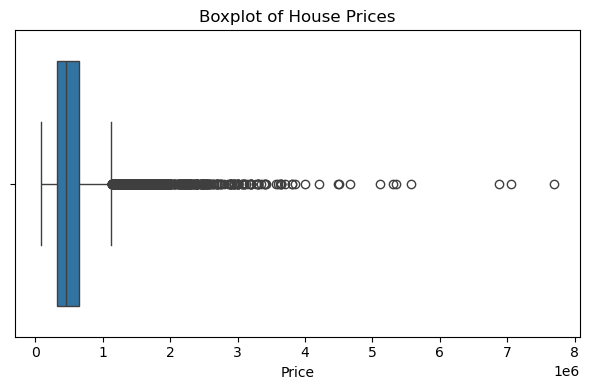

In [6]:
plt.figure(figsize=(6,4))
sns.boxplot(x=Cdata["price"])
plt.title("Boxplot of House Prices")
plt.xlabel("Price")
plt.tight_layout()
plt.show()

In [7]:
# Llogaritja e outliers me IQR
Q1 = Cdata["price"].quantile(0.25)
Q3 = Cdata["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 321950.0
Q3: 645000.0
Lower bound: -162625.0
Upper bound: 1129575.0


In [8]:
# Sa outlier ka ?

price_outliers = Cdata[(Cdata["price"] < lower_bound) | (Cdata["price"] > upper_bound)]
print("Number of price outliers:", price_outliers.shape[0])
print("Percentage:", (price_outliers.shape[0] / data.shape[0]) * 100)

Number of price outliers: 1146
Percentage: 5.302364317771711


In [9]:
# Sa price outlier kemi mbi upper bound 

high_price_outliers = Cdata[Cdata["price"] > upper_bound]
print("High price outliers:", high_price_outliers.shape[0])
high_price_outliers[["price","bedrooms","bathrooms","sqft_living","sqft_lot","grade","waterfront","view"]].sort_values("price", ascending=False).head(20)

High price outliers: 1146


,price,bedrooms,bathrooms,sqft_living,sqft_lot,grade,waterfront,view
7252,7700000.0,6,8.00,12050,27600,13,0,3
3914,7062500.0,5,4.50,10040,37325,11,1,2
9254,6885000.0,6,7.75,9890,31374,13,0,4
4411,5570000.0,5,5.75,9200,35069,13,0,0
1448,5350000.0,5,5.00,8000,23985,12,0,4
1315,5300000.0,6,6.00,7390,24829,12,1,4
1164,5110800.0,5,5.25,8010,45517,12,1,4
8092,4668000.0,5,6.75,9640,13068,12,1,4
2626,4500000.0,5,5.50,6640,40014,12,1,4
8638,4489000.0,4,3.00,6430,27517,12,0,0


In [10]:
# Analiza e 1% të Shtëpive më të Shtrenjta

price_99 = Cdata["price"].quantile(0.99)
print("99th percentile:", price_99)

extreme_price_outliers = Cdata[Cdata["price"] > price_99]
print("Extreme price outliers:", extreme_price_outliers.shape[0])
print("Percentage:", (extreme_price_outliers.shape[0] / Cdata.shape[0]) * 100)

99th percentile: 1964400.0000000051
Extreme price outliers: 217
Percentage: 1.0040253551103502


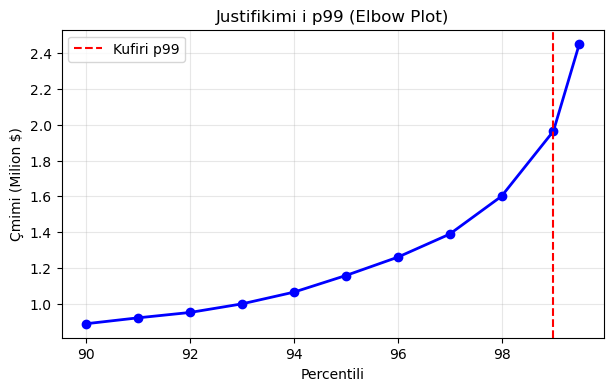

Rritja p98 -> p99:   $364,400
Rritja p99 -> p99.5: $488,890
Rritja p99.5 -> Max: $5,246,710


In [11]:
# 1. Llogaritja e percentileve (nga 90 deri në 99.5)

percentiles = [90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 99.5]
p_values = Cdata["price"].quantile([p/100 for p in percentiles])

# 2. Ndërtimi i grafikut të thjeshtuar

plt.figure(figsize=(7, 4))
plt.plot(percentiles, p_values / 1_000_000, marker='o', color='b', linewidth=2)
plt.axvline(x=99, color='red', linestyle='--', label='Kufiri p99')

plt.xlabel('Percentili')
plt.ylabel('Çmimi (Milion $)')
plt.title('Justifikimi i p99 (Elbow Plot)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Printimi i rritjes matematike (përdorim .diff() për thjeshtësi)

print(f"Rritja p98 -> p99:   ${(p_values[0.99] - p_values[0.98]):,.0f}")
print(f"Rritja p99 -> p99.5: ${(p_values[0.995] - p_values[0.99]):,.0f}")
print(f"Rritja p99.5 -> Max: ${(Cdata['price'].max() - p_values[0.995]):,.0f}")

## 4. Analiza e strukturës (`bedrooms` & `bathrooms`)

In [12]:
Cdata[["bedrooms", "bathrooms"]].describe()

,bedrooms,bathrooms
count,21613.000000,21613.000000
mean,3.370842,2.114757
std,0.930062,0.770163
min,0.000000,0.000000
25%,3.000000,1.750000
50%,3.000000,2.250000
75%,4.000000,2.500000
max,33.000000,8.000000


In [13]:
bedrooms_zero = Cdata[Cdata["bedrooms"] == 0]
print("Rows with 0 bedrooms:", bedrooms_zero.shape[0])
bedrooms_zero[["price","bedrooms","bathrooms","sqft_living","sqft_lot","grade","condition"]]

Rows with 0 bedrooms: 13


,price,bedrooms,bathrooms,sqft_living,sqft_lot,grade,condition
875,1095000.0,0,0.00,3064,4764,7,3
3119,380000.0,0,0.00,1470,979,8,3
3467,288000.0,0,1.50,1430,1650,7,3
4868,228000.0,0,1.00,390,5900,4,2
6994,1295650.0,0,0.00,4810,28008,12,3
8477,339950.0,0,2.50,2290,8319,8,3
8484,240000.0,0,2.50,1810,5669,7,3
9773,355000.0,0,0.00,2460,8049,8,3
9854,235000.0,0,0.00,1470,4800,7,3
12653,320000.0,0,2.50,1490,7111,7,3


In [14]:
bathrooms_zero = Cdata[Cdata["bathrooms"] == 0]
print("Rows with 0 bathrooms:", bathrooms_zero.shape[0])
bathrooms_zero[["price","bedrooms","bathrooms","sqft_living","sqft_lot","grade","condition"]]

Rows with 0 bathrooms: 10


,price,bedrooms,bathrooms,sqft_living,sqft_lot,grade,condition
875,1095000.0,0,0.0,3064,4764,7,3
1149,75000.0,1,0.0,670,43377,3,3
3119,380000.0,0,0.0,1470,979,8,3
5832,280000.0,1,0.0,600,24501,3,2
6994,1295650.0,0,0.0,4810,28008,12,3
9773,355000.0,0,0.0,2460,8049,8,3
9854,235000.0,0,0.0,1470,4800,7,3
10481,484000.0,1,0.0,690,23244,7,4
14423,139950.0,0,0.0,844,4269,7,4
19452,142000.0,0,0.0,290,20875,1,1


In [15]:
Cdata.sort_values("bedrooms", ascending=False)[
    ["price","bedrooms","bathrooms","sqft_living","sqft_lot","grade","condition"]
].head(15)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,grade,condition
15870,640000.0,33,1.75,1620,6000,7,5
8757,520000.0,11,3.00,3000,4960,7,3
19254,660000.0,10,3.00,2920,3745,7,4
15161,650000.0,10,2.00,3610,11914,7,4
13314,1148000.0,10,5.25,4590,10920,9,3
6079,1280000.0,9,4.50,3650,5000,8,3
8546,450000.0,9,7.50,4050,6504,7,3
4235,700000.0,9,3.00,3680,4400,7,3
16844,1400000.0,9,4.00,4620,5508,11,3
18443,934000.0,9,3.00,2820,4480,7,3


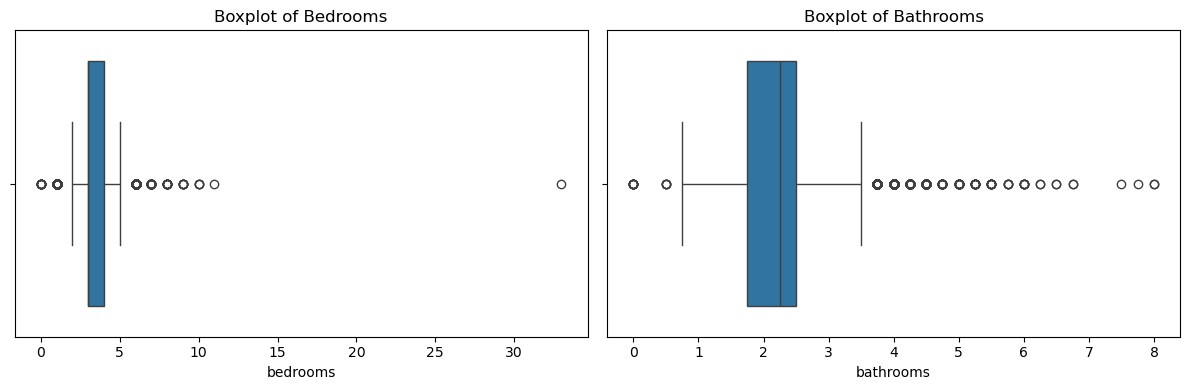

In [16]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x=Cdata["bedrooms"])
plt.title("Boxplot of Bedrooms")
plt.subplot(1, 2, 2)
sns.boxplot(x=Cdata["bathrooms"])
plt.title("Boxplot of Bathrooms")
plt.tight_layout()
plt.show()

## 5. Analiza e sipërfaqes jetueshme (`sqft_living`)

In [17]:
Cdata["sqft_living"].describe()

count    21613.000000
mean      2079.899736
std        918.440897
min        290.000000
25%       1427.000000
50%       1910.000000
75%       2550.000000
max      13540.000000
Name: sqft_living, dtype: float64

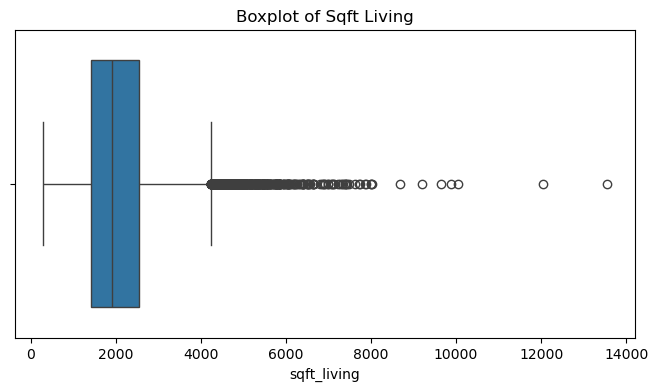

In [18]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=Cdata["sqft_living"])
plt.title("Boxplot of Sqft Living")
plt.xlabel("sqft_living")
plt.show()

In [19]:
Cdata.sort_values("sqft_living", ascending=False)[
    ["price","bedrooms","bathrooms","sqft_living","sqft_lot","grade","condition","waterfront","view"]
].head(20)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,grade,condition,waterfront,view
12777,2280000.0,7,8.00,13540,307752,12,3,0,4
7252,7700000.0,6,8.00,12050,27600,13,4,0,3
3914,7062500.0,5,4.50,10040,37325,11,3,1,2
9254,6885000.0,6,7.75,9890,31374,13,3,0,4
8092,4668000.0,5,6.75,9640,13068,12,3,1,4
4411,5570000.0,5,5.75,9200,35069,13,3,0,0
14556,2888000.0,5,6.25,8670,64033,13,3,0,4
18302,3300000.0,5,6.25,8020,21738,11,3,0,0
1164,5110800.0,5,5.25,8010,45517,12,3,1,4
1448,5350000.0,5,5.00,8000,23985,12,3,0,4


In [20]:
Cdata[Cdata["sqft_living"] < 500][
    ["price","bedrooms","bathrooms","sqft_living","grade","condition"]
].sort_values("sqft_living")

,price,bedrooms,bathrooms,sqft_living,grade,condition
19452,142000.0,0,0.00,290,1,1
15381,276000.0,1,0.75,370,5,5
860,245000.0,1,0.75,380,5,3
18379,265000.0,0,0.75,384,4,3
4868,228000.0,0,1.00,390,4,2
21332,245000.0,1,1.00,390,6,4
8623,325000.0,1,0.75,410,4,2
14466,280000.0,1,0.75,420,5,3
11500,229050.0,1,1.00,420,4,4
465,80000.0,1,0.75,430,4,2


## 6. Analiza e parcelës (`sqft_lot` dhe `sqft_lot15`)

In [21]:
Cdata[["sqft_lot", "sqft_lot15"]].describe().round(2)

,sqft_lot,sqft_lot15
count,21613.00,21613.00
mean,15106.97,12768.46
std,41420.51,27304.18
min,520.00,651.00
25%,5040.00,5100.00
50%,7618.00,7620.00
75%,10688.00,10083.00
max,1651359.00,871200.00


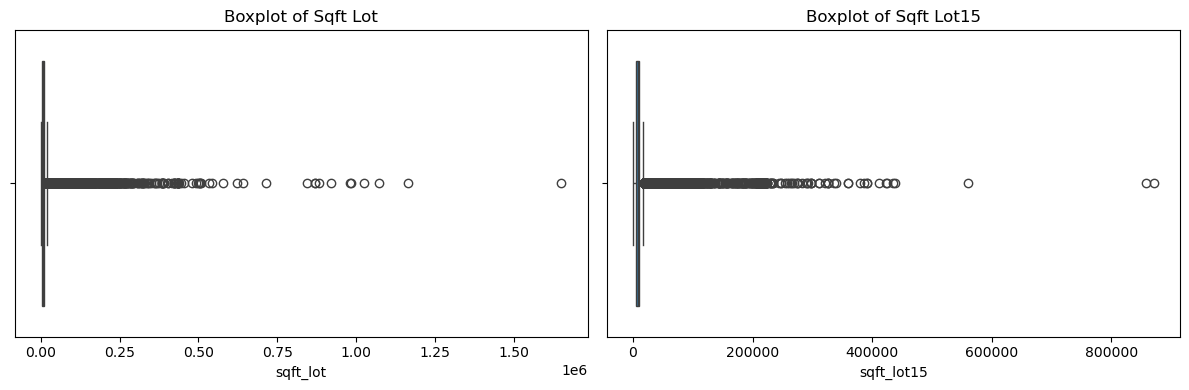

In [22]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x=Cdata["sqft_lot"])
plt.title("Boxplot of Sqft Lot")
plt.subplot(1, 2, 2)
sns.boxplot(x=Cdata["sqft_lot15"])
plt.title("Boxplot of Sqft Lot15")
plt.tight_layout()
plt.show()

In [23]:
# Justifikim statistikor per sqft_lot outliers

print("=== Analiza Statistikore e sqft_lot ===")
print(f"Skewness sqft_lot:    {Cdata['sqft_lot'].skew():.2f}")
print(f"Skewness sqft_living: {Cdata['sqft_living'].skew():.2f}  (krahasim)")

corr_lot    = Cdata["sqft_lot"].corr(Cdata["price"])
corr_living = Cdata["sqft_living"].corr(Cdata["price"])
print(f"Korrelacioni sqft_lot    me price: {corr_lot:.3f}")
print(f"Korrelacioni sqft_living me price: {corr_living:.3f}")
print("-> Korrelacioni i ulet tregon se sqft_lot nuk eshte feature kyçe")

=== Analiza Statistikore e sqft_lot ===
Skewness sqft_lot:    13.06
Skewness sqft_living: 1.47  (krahasim)
Korrelacioni sqft_lot    me price: 0.090
Korrelacioni sqft_living me price: 0.702
-> Korrelacioni i ulet tregon se sqft_lot nuk eshte feature kyçe


In [24]:
# Eksplorimi i Top 20 Shtëpive sipas Sipërfaqes së Tokës

Cdata.sort_values("sqft_lot", ascending=False)[
    ["price", "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "sqft_lot15", "grade", "condition"]
].head(20)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,sqft_lot15,grade,condition
1719,700000.0,4,1.00,1300,1651359,425581,6,4
17319,190000.0,2,1.00,710,1164794,16730,5,2
7647,542500.0,5,3.25,3010,1074218,68825,8,5
7769,855000.0,4,3.50,4030,1024068,11700,10,3
3949,998000.0,4,3.25,3770,982998,37141,10,3
4441,790000.0,2,3.00,2560,982278,40946,8,3
6691,1998000.0,2,2.50,3900,920423,411962,12,3
7077,1650000.0,4,3.25,3920,881654,112384,11,3
20452,1600000.0,4,5.50,6530,871200,858132,11,3
9714,937500.0,4,4.00,5545,871200,871200,11,3


In [25]:
# Identifikimi i Lagjeve me Parcelat më të Mëdha të Tokës

Cdata.sort_values("sqft_lot15", ascending=False)[
    ["price", "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "sqft_lot15", "grade", "condition"]
].head(20)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,sqft_lot15,grade,condition
9714,937500.0,4,4.00,5545,871200,871200,11,3
20452,1600000.0,4,5.50,6530,871200,858132,11,3
13464,790000.0,3,2.50,2640,432036,560617,10,3
8664,549950.0,3,1.75,2930,266587,438213,8,3
3801,637000.0,4,3.50,3080,118918,434728,9,3
1719,700000.0,4,1.00,1300,1651359,425581,6,4
19156,858000.0,4,3.50,4370,422967,422967,10,4
6691,1998000.0,2,2.50,3900,920423,411962,12,3
15620,180000.0,2,1.00,960,87991,392040,5,3
21431,800000.0,4,3.25,3540,159430,392040,9,3


In [26]:
# Kontroll logjik: sqft_living = sqft_above + sqft_basement

living_mismatch = Cdata[Cdata["sqft_living"] != Cdata["sqft_above"] + Cdata["sqft_basement"]]
print("Rows where sqft_living != sqft_above + sqft_basement:", living_mismatch.shape[0])

Rows where sqft_living != sqft_above + sqft_basement: 0


In [27]:
# Kontroll: sqft_living > sqft_lot

living_greater = Cdata[Cdata["sqft_living"] > Cdata["sqft_lot"]]
print("Rows where sqft_living > sqft_lot:", living_greater.shape[0])
print("Percentage:", (living_greater.shape[0] / Cdata.shape[0]) * 100)

Rows where sqft_living > sqft_lot: 789
Percentage: 3.65058066904178


## 7. Analiza e podrumit (`sqft_basement`)

In [28]:
Cdata["sqft_basement"].describe().round(2)

count    21613.00
mean       291.51
std        442.58
min          0.00
25%          0.00
50%          0.00
75%        560.00
max       4820.00
Name: sqft_basement, dtype: float64

In [29]:
basement_zero = Cdata[Cdata["sqft_basement"] == 0]
print("Rows with no basement:", basement_zero.shape[0])
print("Percentage with no basement:", (basement_zero.shape[0] / Cdata.shape[0]) * 100)

Rows with no basement: 13126
Percentage with no basement: 60.73196687179012


In [30]:
basement_existing = Cdata[Cdata["sqft_basement"] > 0]

print("Rows with basement:", basement_existing.shape[0])
print("Percentage with basement:", (basement_existing.shape[0] / Cdata.shape[0]) * 100)


Rows with basement: 8487
Percentage with basement: 39.26803312820987


In [31]:
Cdata[Cdata["sqft_basement"] < 0]


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15


In [32]:
# Analiza e Shtëpive me Bodrumet më të Mëdha

Cdata.sort_values("sqft_basement", ascending=False)[
    ["price", "bedrooms", "bathrooms", "sqft_living", "sqft_basement", "sqft_above", "grade", "condition"]
].head(20)

,price,bedrooms,bathrooms,sqft_living,sqft_basement,sqft_above,grade,condition
8092,4668000.0,5,6.75,9640,4820,4820,12,3
12777,2280000.0,7,8.00,13540,4130,9410,12,3
15482,3200000.0,4,3.25,7000,3500,3500,12,4
7252,7700000.0,6,8.00,12050,3480,8570,13,4
10085,1900000.0,5,4.25,6510,3260,3250,11,4
4411,5570000.0,5,5.75,9200,3000,6200,13,3
5049,1385000.0,6,2.75,5700,2850,2850,10,4
21344,1488000.0,5,6.00,6880,2810,4070,12,3
7035,3800000.0,5,5.50,7050,2730,4320,13,4
6628,850000.0,4,2.75,5440,2720,2720,9,2


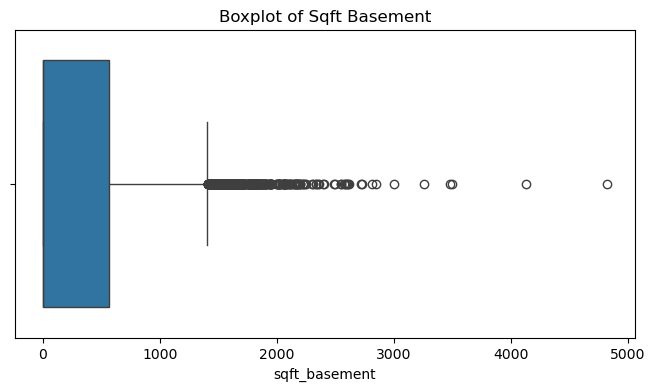

In [33]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=Cdata["sqft_basement"])
plt.title("Boxplot of Sqft Basement")
plt.xlabel("sqft_basement")
plt.show()

## 8. Kolonat diskrete (`waterfront`, `view`, `condition`, `grade`)

In [34]:
discrete_cols = [
    "bedrooms",
    "bathrooms",
    "floors",
    "waterfront",
    "view",
    "condition",
    "grade",
    "yr_built",
    "yr_renovated",
    "zipcode"
]

In [35]:
# Analiza e Vlerave Unike për Kolonat e Diskreta

for col in discrete_cols:
    print(f"\nValue counts for {col}:")
    print(Cdata[col].value_counts().sort_index())


Value counts for bedrooms:
bedrooms
0       13
1      199
2     2760
3     9824
4     6882
5     1601
6      272
7       38
8       13
9        6
10       3
11       1
33       1
Name: count, dtype: int64

Value counts for bathrooms:
bathrooms
0.00      10
0.50       4
0.75      72
1.00    3852
1.25       9
1.50    1446
1.75    3048
2.00    1930
2.25    2047
2.50    5380
2.75    1185
3.00     753
3.25     589
3.50     731
3.75     155
4.00     136
4.25      79
4.50     100
4.75      23
5.00      21
5.25      13
5.50      10
5.75       4
6.00       6
6.25       2
6.50       2
6.75       2
7.50       1
7.75       1
8.00       2
Name: count, dtype: int64

Value counts for floors:
floors
1.0    10680
1.5     1910
2.0     8241
2.5      161
3.0      613
3.5        8
Name: count, dtype: int64

Value counts for waterfront:
waterfront
0    21450
1      163
Name: count, dtype: int64

Value counts for view:
view
0    19489
1      332
2      963
3      510
4      319
Name: count, dtype: int64

Va

In [36]:
# Validimi i Vlerave të Lejuara në Kolonat Kategorike

invalid_waterfront = Cdata[~Cdata["waterfront"].isin([0, 1])]
invalid_view       = Cdata[~Cdata["view"].between(0, 4)]
invalid_condition  = Cdata[~Cdata["condition"].between(1, 5)]
invalid_grade      = Cdata[~Cdata["grade"].between(1, 13)]

print("Invalid waterfront rows:", invalid_waterfront.shape[0])
print("Invalid view rows:",       invalid_view.shape[0])
print("Invalid condition rows:",  invalid_condition.shape[0])
print("Invalid grade rows:",      invalid_grade.shape[0])

Invalid waterfront rows: 0
Invalid view rows: 0
Invalid condition rows: 0
Invalid grade rows: 0


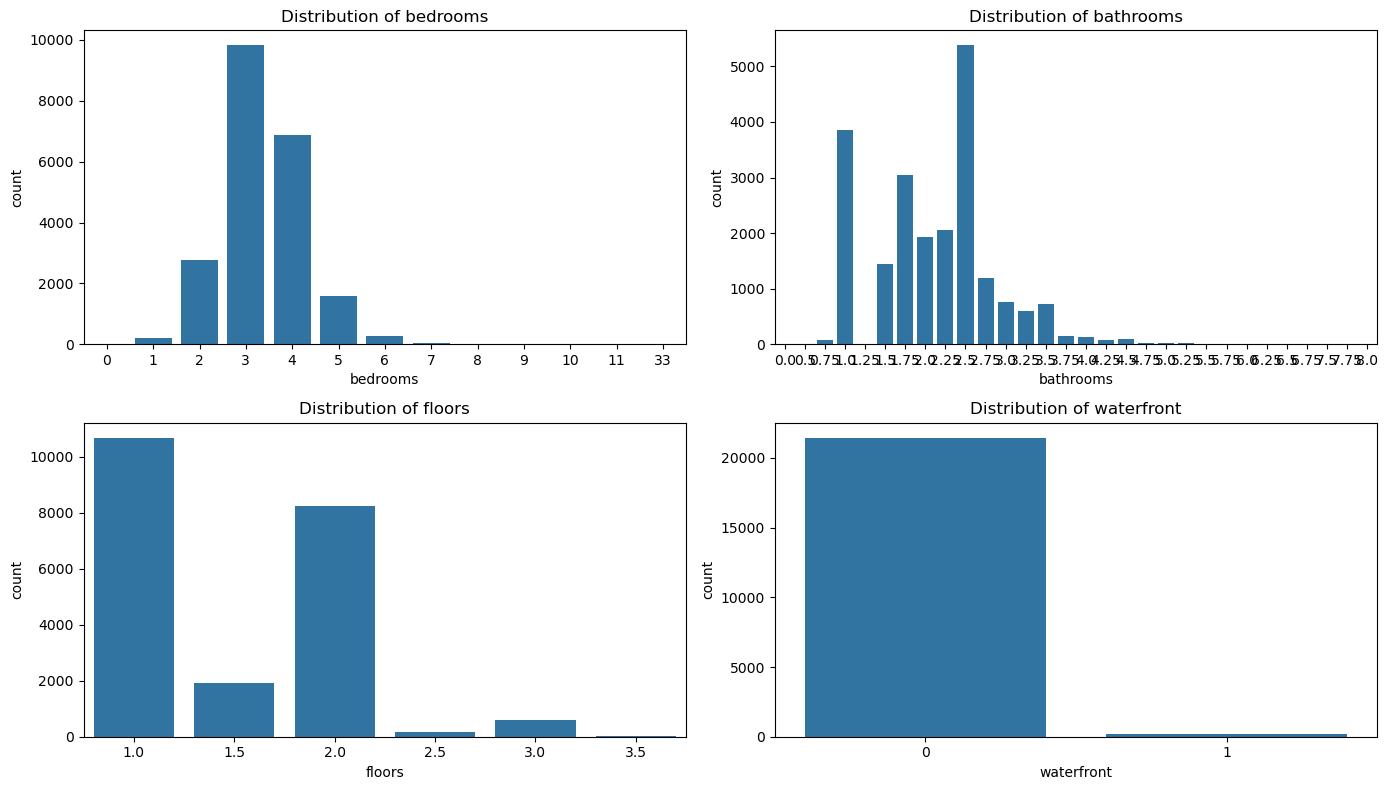

In [37]:
plt.figure(figsize=(14, 8))

for i, col in enumerate(discrete_cols[:4], 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=Cdata[col])
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

## 9. Analiza e koordinatave gjeografike

In [38]:
Cdata[["lat", "long"]].describe().round(4)

,lat,long
count,21613.0000,21613.0000
mean,47.5601,-122.2139
std,0.1386,0.1408
min,47.1559,-122.5190
25%,47.4710,-122.3280
50%,47.5718,-122.2300
75%,47.6780,-122.1250
max,47.7776,-121.3150


In [39]:
# Kontrolli i Kufijve Gjeografikë (Latitude & Longitude)

invalid_geo = Cdata[
    (Cdata["lat"] < 47.1) | (Cdata["lat"] > 47.8) |
    (Cdata["long"] < -122.6) | (Cdata["long"] > -121.2)
]
print("Rows with invalid geographic values:", invalid_geo.shape[0])

Rows with invalid geographic values: 0


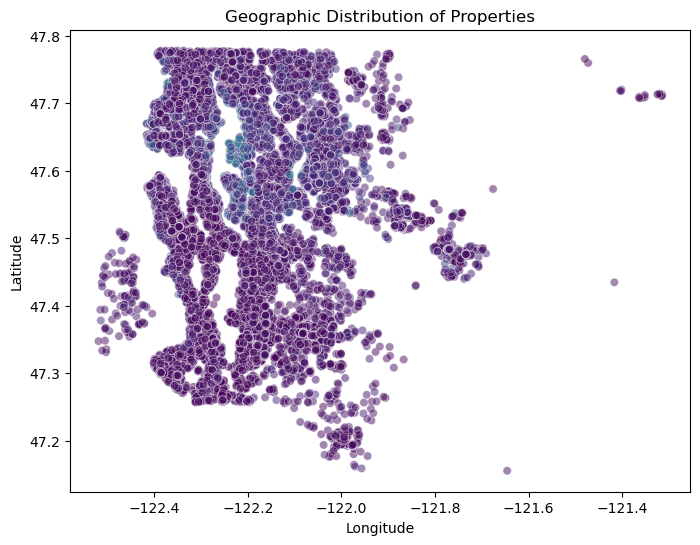

In [40]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=Cdata, x="long", y="lat", hue="price",
                palette="viridis", alpha=0.5, legend=False)
plt.title("Geographic Distribution of Properties")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## 10. Përmbledhje e gjetjeve nga analiza eksploruese

Nga analiza fillestare e dataset-it `kc_house_data`, u identifikuan këto pika kryesore:

- Dataset-i nuk përmban vlera të munguara.
- Nuk u identifikuan rreshta të duplikuar..
- Kolonat `bedrooms` dhe `bathrooms` përmbajnë disa raste me vlerë `0`. Këto raste nuk janë realiste për një pronë banimi dhe do të trajtohen në fazën e pastrimit të të dhënave.
- Kolona `price` paraqet shpërndarje të anuar djathtas, me disa vlera shumë të larta. Këto outliers mund të ndikojnë ndjeshëm në modelet e regresionit dhe do të filtrohen duke përdorur pragun `p99`, pas ndarjes train/validation/test për të shmangur data leakage.
- Variablat numerike si `sqft_living`, `sqft_lot`, `sqft_above` dhe `sqft_basement` gjithashtu përmbajnë vlera ekstreme. Megjithatë, këto duken si raste reale të pronave me sipërfaqe shumë të mëdha, prandaj nuk do të largohen automatikisht.
- Variablat gjeografike `lat` dhe `long` kanë vlera brenda intervaleve të pritshme për zonën e King County, pa anomali të dukshme.
- Kolonat diskrete si `bedrooms`, `bathrooms`, `floors`, `condition`, `grade`, `view` dhe `waterfront` kanë vlera përgjithësisht brenda intervaleve të pritshme.
- Kolonat `grade`, `sqft_living`, `bathrooms`, `sqft_above` dhe `view` shfaqin lidhje të dukshme me `price`, prandaj pritet të jenë variabla të rëndësishme për modelim.
- Kolona `date` duhet të konvertohet në format datetime dhe mund të përdoret për të krijuar veçori të reja si `year_sold` dhe `month_sold`.
- Kolonat `id` dhe `date` në formën origjinale nuk janë të përshtatshme për modelim direkt dhe do të trajtohen në fazat pasuese.

Në përgjithësi, dataset-i është relativisht i pastër dhe i përshtatshëm për modelim, por kërkon disa hapa të rëndësishëm pastrimi dhe transformimi para ndërtimit të modeleve prediktive.